# makemore exercises

## bigram language model - counting approach

In [1]:
import torch
import matplotlib.pyplot as plt

torch.set_printoptions(linewidth=200, threshold=10_000)

%matplotlib inline

In [2]:
words = open("../data/names.txt", "r").read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [9]:
chars = sorted(set("".join(words)))  # <- list of chars from "a" to "z"
stoi = {s: i + 1 for i, s in enumerate(chars)}  # <- dict, {".": 0, "a": 1, "b": 2 ...}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}  # <- dict, {0: ".", 1: "a", 2: "b" ...}

In [5]:
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

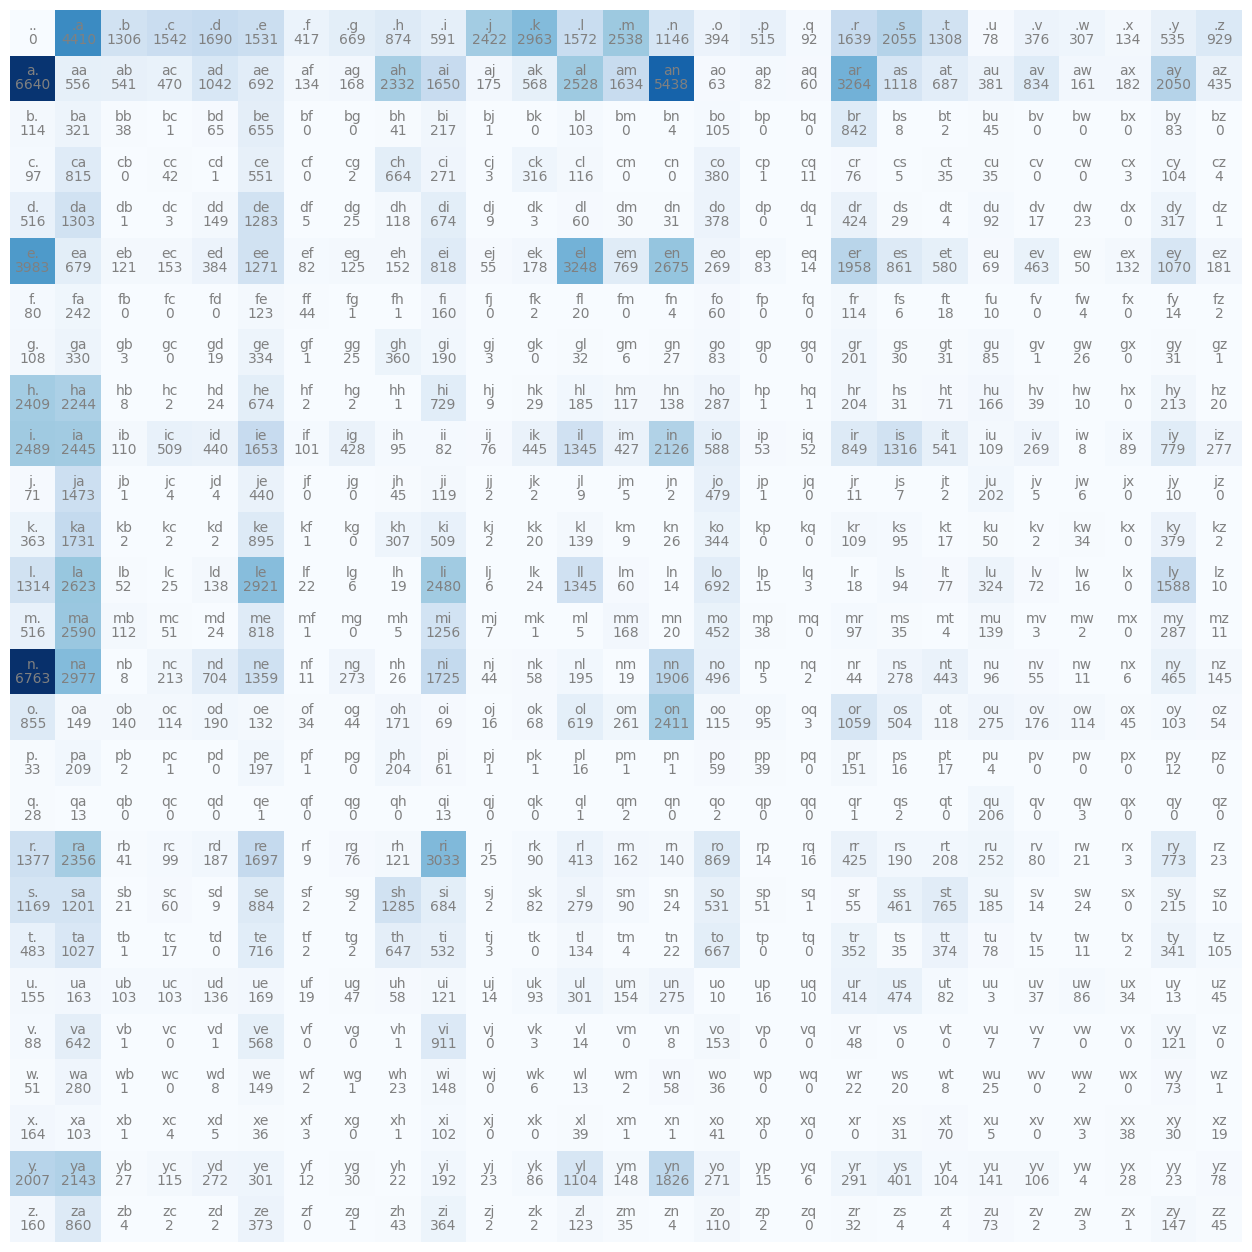

In [6]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis("off");

In [7]:
# normalized, prbability
P = (N + 1).float()  # <- "+1" is the smoothing
P /= P.sum(1, keepdims=True)

In [8]:
P[0].sum()

tensor(1.)

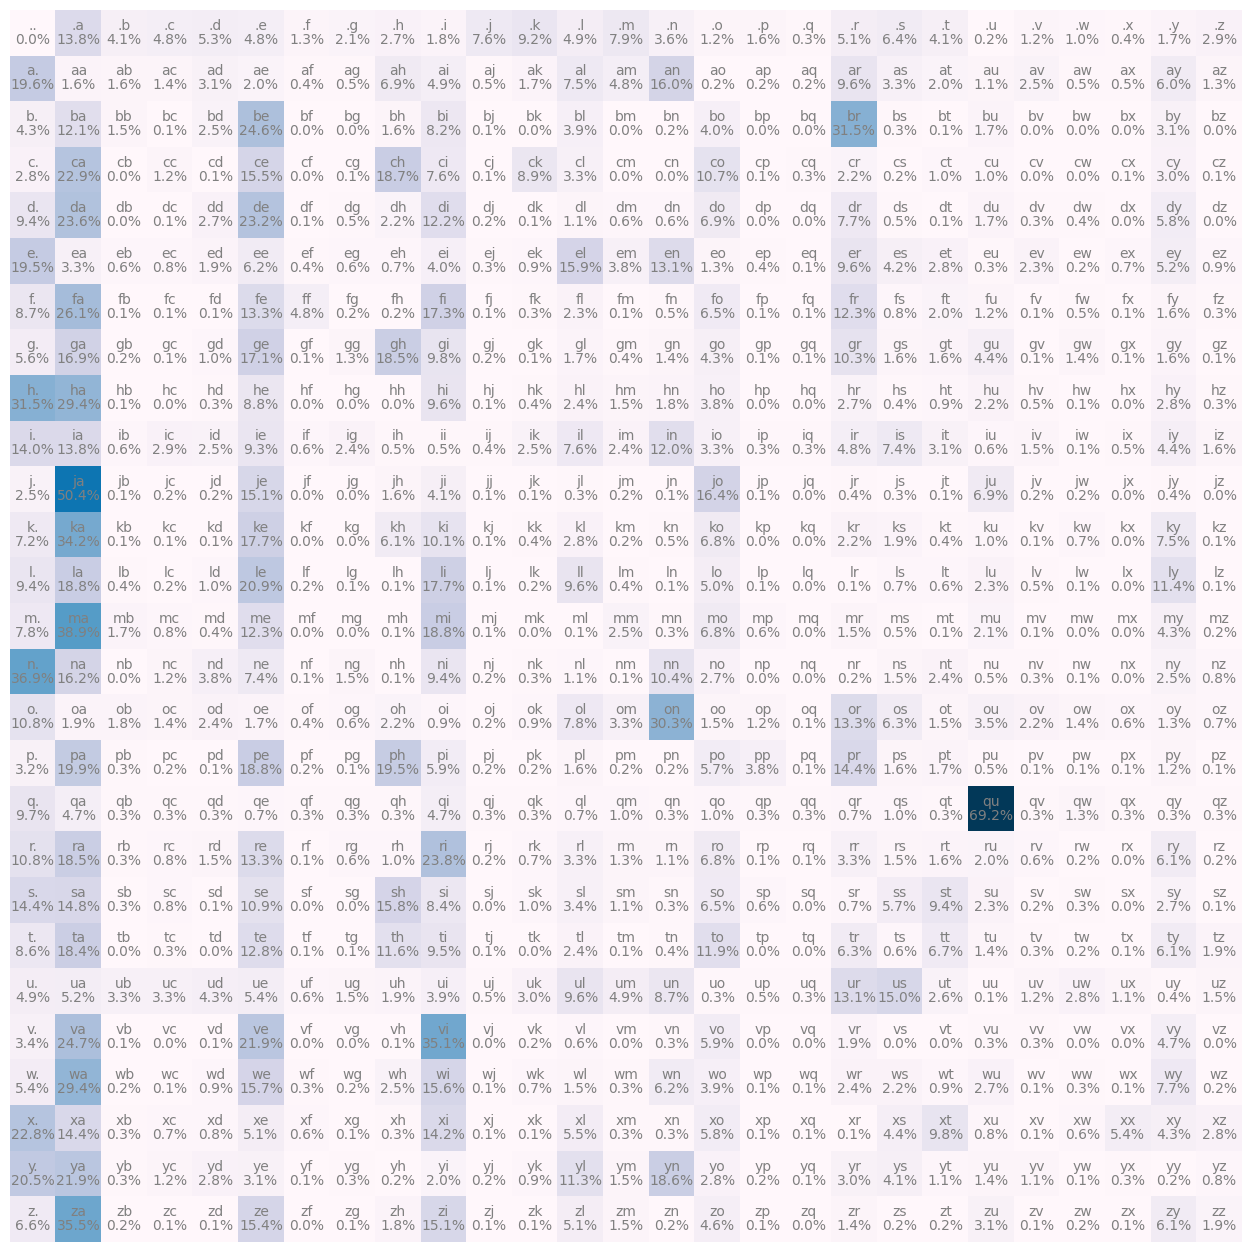

In [9]:
plt.figure(figsize=(16, 16))
plt.imshow(P, cmap="PuBu")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, f"{P[i, j].item():.1%}", ha="center", va="top", color="gray")
plt.axis("off");

In [10]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]

        # randomly sample the next char using the probs learned from the data
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()

        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


## bigram language model - nn approach

In [11]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [12]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f"{log_likelihood=}")
nll = -log_likelihood
print(f"{nll=}")
avg_nll = nll / n
print(f"{avg_nll=}")

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
avg_nll=tensor(2.4544)


In [13]:
# create the training set of bigrams (x,y)
xs, ys = [], []

for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(f"{ch1} -> {ch2}")
        xs.append(ix1)
        ys.append(ix2)

for x, y in zip(xs, ys):
    print(f"{x=} -> {y=}")

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. -> e
e -> m
m -> m
m -> a
a -> .
x=0 -> y=5
x=5 -> y=13
x=13 -> y=13
x=13 -> y=1
x=1 -> y=0


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


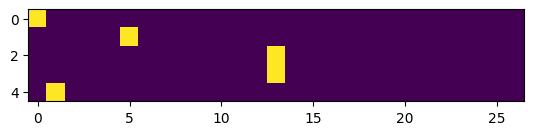

In [14]:
import torch.nn.functional as F

# input to the network: one-hot encoding
xenc = F.one_hot(xs, num_classes=27).float()
print(xenc)

plt.imshow(xenc)

In [15]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [16]:
# "@": dot product in pytorch
print(f"{xenc.shape} @ {W.shape} -> {(xenc @ W).shape}")

torch.Size([5, 27]) @ torch.Size([27, 27]) -> torch.Size([5, 27])


In [17]:
for _ in range(10):
    # forward pass
    logits = xenc @ W  # predict log-counts
    # --- softmax ---
    counts = logits.exp()  # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True)  # probabilities for next character
    # ---------------
    loss = -probs[torch.arange(5), ys].log().mean()
    print(f"{loss.item()=}")

    # backward pass
    W.grad = None  # set to zero the gradient
    loss.backward()

    W.data += -0.1 * W.grad

loss.item()=3.7693049907684326
loss.item()=3.7492127418518066
loss.item()=3.7291626930236816
loss.item()=3.7091541290283203
loss.item()=3.6891887187957764
loss.item()=3.6692662239074707
loss.item()=3.6493873596191406
loss.item()=3.629552125930786
loss.item()=3.6097614765167236
loss.item()=3.5900158882141113


In [18]:
# --------- !!! OPTIMIZATION !!! yay, but this time actually --------------

In [19]:
# create the dataset
xs, ys = [], []
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print("number of examples: ", num)

# input to the network: one-hot encoding
xenc = F.one_hot(xs, num_classes=27).float()

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [20]:
print(f"{xenc.shape} @ {W.shape} -> {(xenc @ W).shape}")

torch.Size([228146, 27]) @ torch.Size([27, 27]) -> torch.Size([228146, 27])


In [21]:
# gradient descent
for k in range(500):
    # forward pass
    logits = xenc @ W  # predict log-counts
    counts = logits.exp()  # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True)  # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()

    if k % 50 == 0:
        print(f"{loss.item()=}")

    # backward pass
    W.grad = None  # set to zero the gradient
    loss.backward()

    # update
    W.data += -50 * W.grad

loss.item()=3.7686190605163574


loss.item()=2.509854793548584
loss.item()=2.4899587631225586
loss.item()=2.484916925430298
loss.item()=2.4829699993133545
loss.item()=2.482024908065796
loss.item()=2.481499195098877
loss.item()=2.481180191040039
loss.item()=2.4809749126434326
loss.item()=2.4808356761932373


In [22]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        # ----------
        # BEFORE:
        # p = P[ix]
        # ----------
        # NOW:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W  # predict log-counts
        counts = logits.exp()  # counts, equivalent to N
        p = counts / counts.sum(1, keepdims=True)  # probabilities for next character
        # ----------

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.


In [23]:
# let's inspect the probability learned by the model
encs = F.one_hot(torch.tensor(range(27)), num_classes=27).float()
logits = encs @ W
counts = logits.exp()
P = counts / counts.sum(1, keepdims=True)

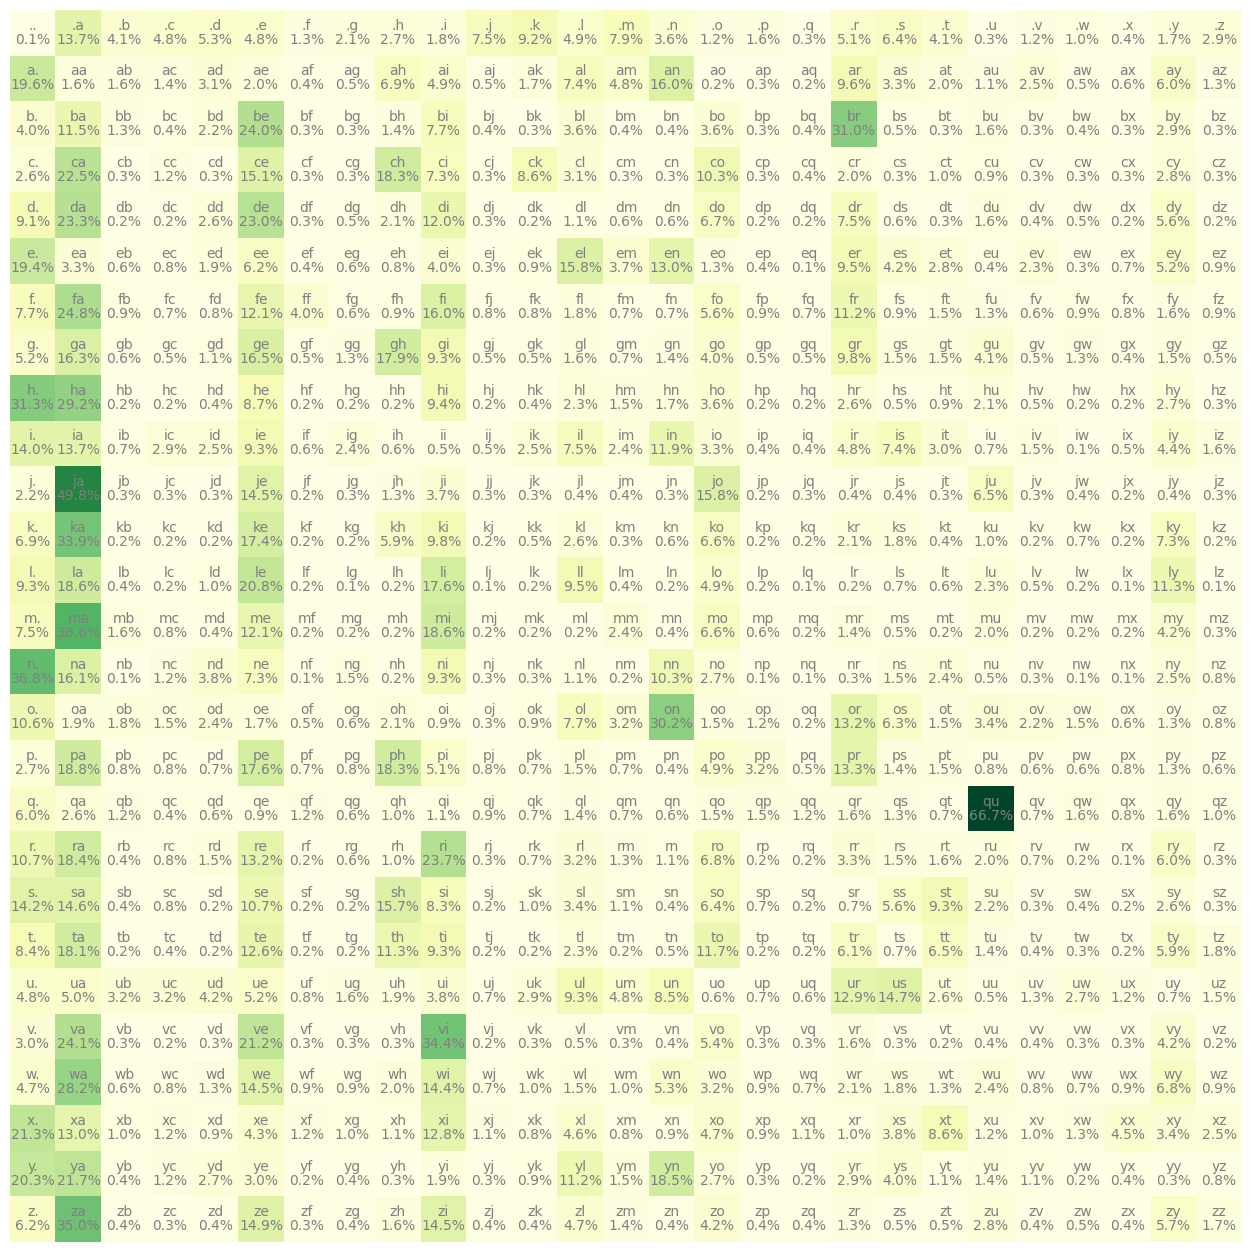

In [24]:
plt.figure(figsize=(16, 16))
p = P.detach().numpy()
plt.imshow(p, cmap="YlGn")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, f"{p[i, j].item():.1%}", ha="center", va="top", color="gray")
plt.axis("off");

## exercises

Exercises:\
E01: train a trigram language model, i.e. take two characters as an input to predict the 3rd one. Feel free to use either counting or a neural net. Evaluate the loss; Did it improve over a bigram model?\
E02: split up the dataset randomly into 80% train set, 10% dev set, 10% test set. Train the bigram and trigram models only on the training set. Evaluate them on dev and test splits. What can you see?\
E03: use the dev set to tune the strength of smoothing (or regularization) for the trigram model - i.e. try many possibilities and see which one works best based on the dev set loss. What patterns can you see in the train and dev set loss as you tune this strength? Take the best setting of the smoothing and evaluate on the test set once and at the end. How good of a loss do you achieve?\
E04: we saw that our 1-hot vectors merely select a row of W, so producing these vectors explicitly feels wasteful. Can you delete our use of F.one_hot in favor of simply indexing into rows of W?\
E05: look up and use F.cross_entropy instead. You should achieve the same result. Can you think of why we'd prefer to use F.cross_entropy instead?\
E06: meta-exercise! Think of a fun/interesting exercise and complete it.

### E01:
train a trigram language model, i.e. take two characters as an input to predict the 3rd one. Feel free to use either counting or a neural net. Evaluate the loss; Did it improve over a bigram model?

In [11]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.set_printoptions(linewidth=200, threshold=10_000)

%matplotlib inline

In [2]:
words = open("../data/names.txt", "r").read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

### trigram - counting approach

In [27]:
# trigram: 3 dimensional
N = torch.zeros((27, 27, 27), dtype=torch.int32)

In [28]:
chars = sorted(set("".join(words)))  # <- list of chars from "a" to "z"
stoi = {s: i + 1 for i, s in enumerate(chars)}  # <- dict, {".": 0, "a": 1, "b": 2 ...}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}  # <- dict, {0: ".", 1: "a", 2: "b" ...}

In [29]:
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1, ix2, ix3 = stoi[ch1], stoi[ch2], stoi[ch3]
        N[ix1, ix2, ix3] += 1

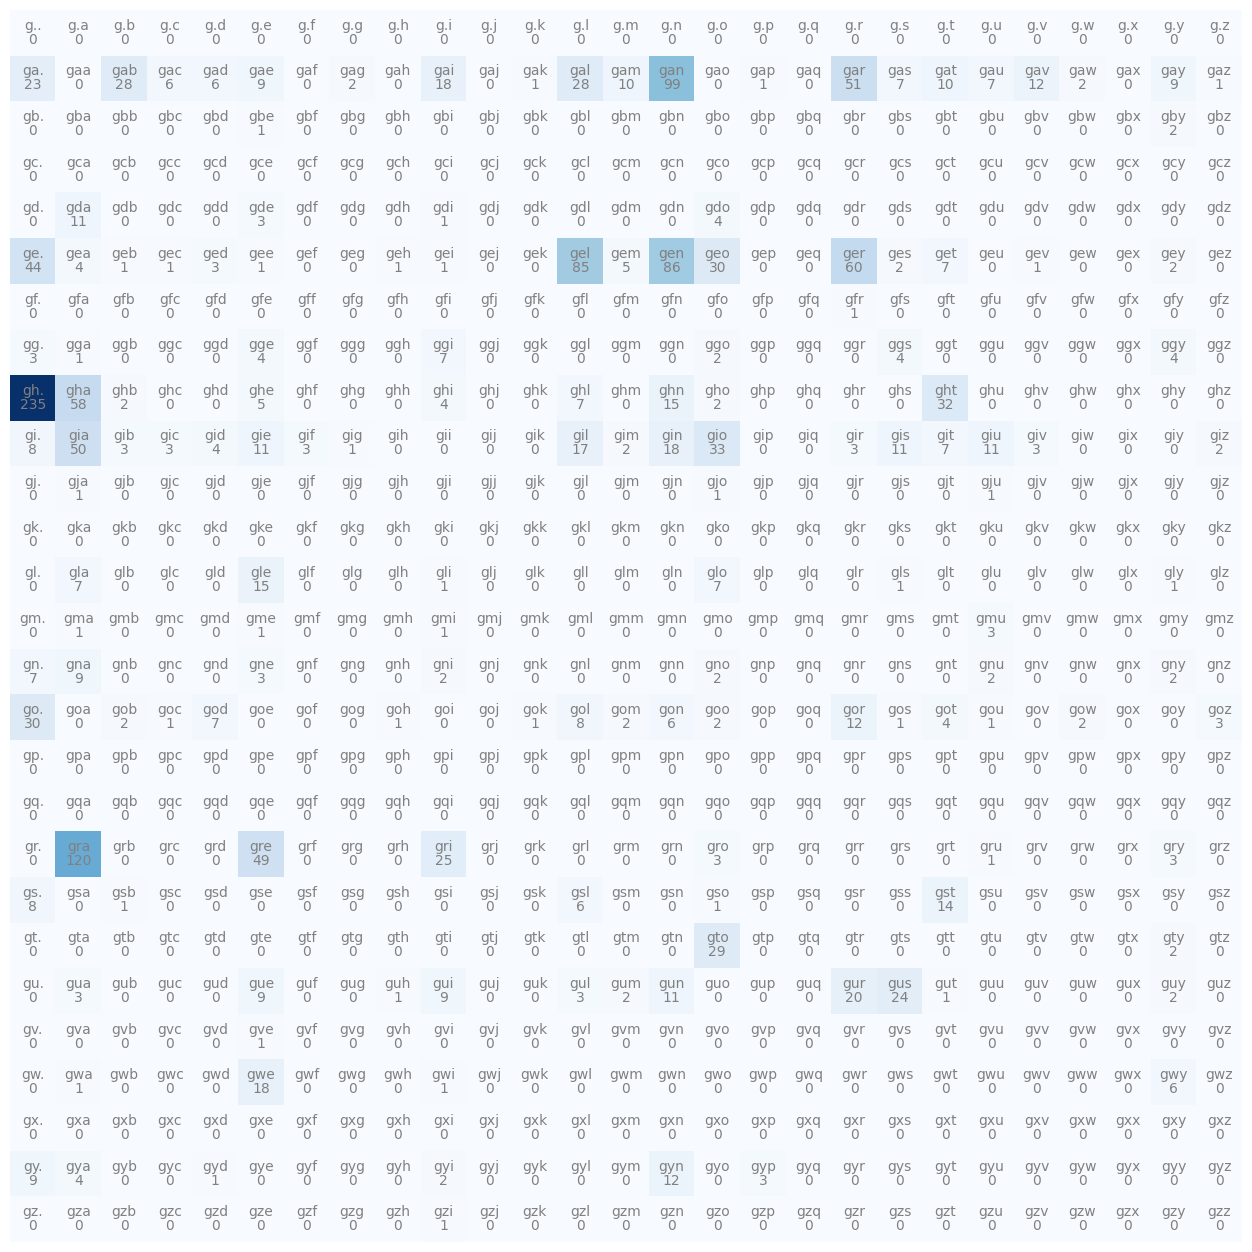

In [30]:
example_ix = 7
first = itos[example_ix]
n = N[example_ix]

plt.figure(figsize=(16, 16))
plt.imshow(n, cmap="Blues")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, first + chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, n[i, j].item(), ha="center", va="top", color="gray")
plt.axis("off");

In [31]:
P = (N + 1).float()
P /= P.sum(dim=2, keepdims=True)

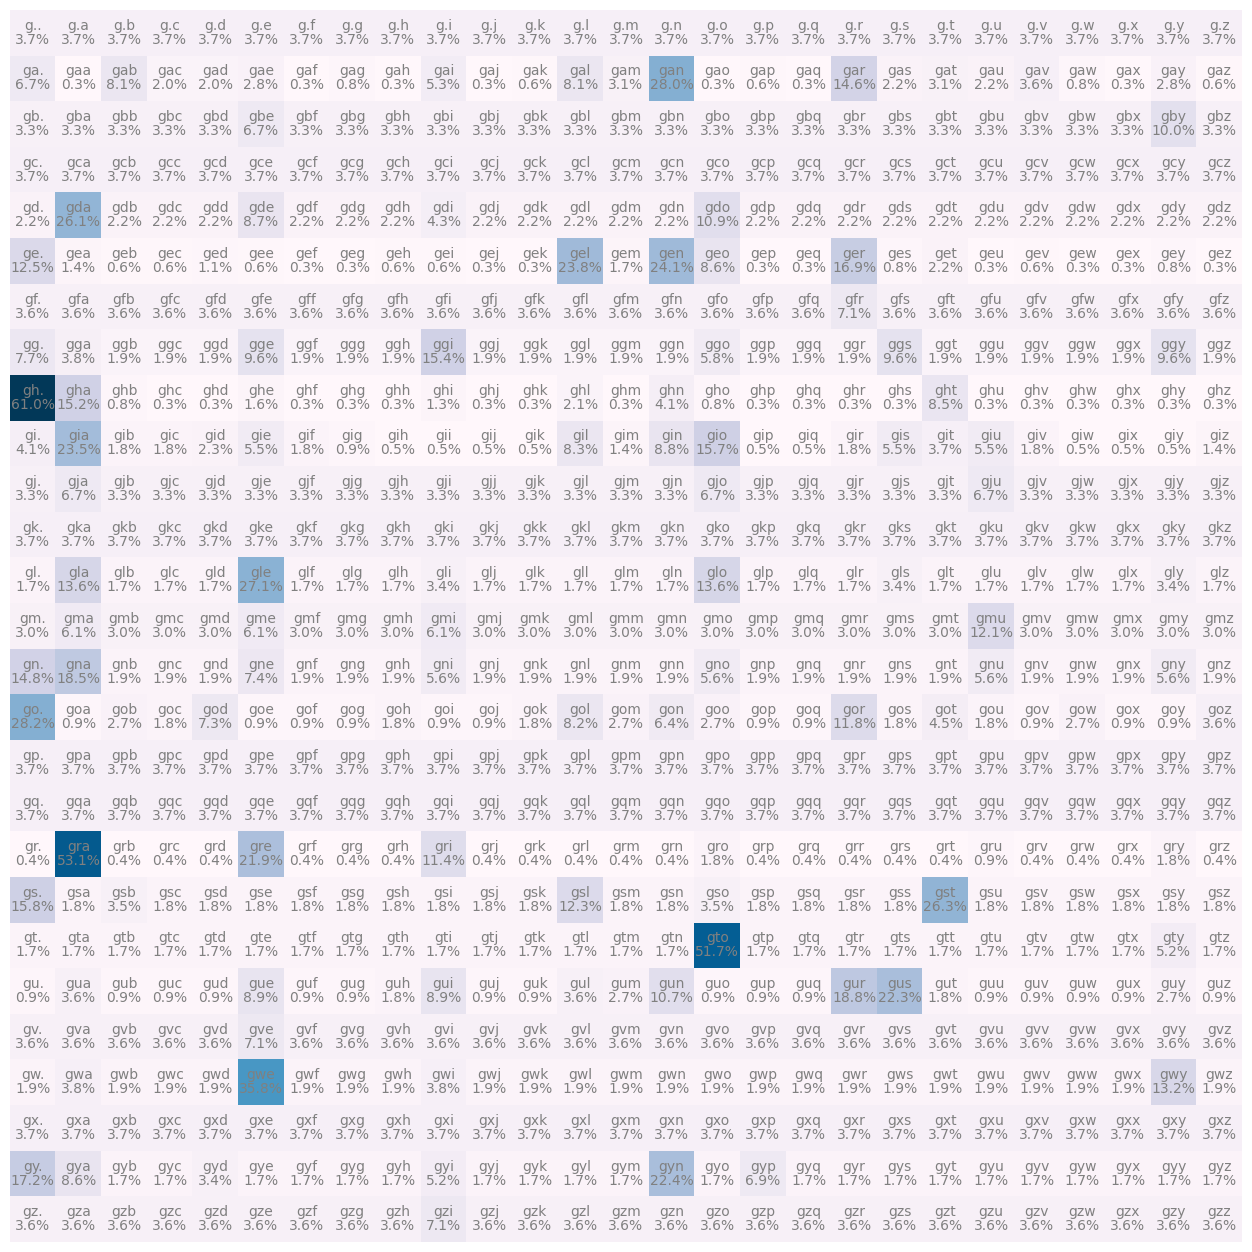

In [32]:
example_ix = 7
first = itos[example_ix]
p = P[example_ix]

plt.figure(figsize=(16, 16))
plt.imshow(p, cmap="PuBu")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, first + chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, f"{p[i, j].item():.1%}", ha="center", va="top", color="gray")
plt.axis("off");

In [33]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix1, ix2 = 0, 0
    while True:
        p = P[ix1, ix2]

        # randomly sample the next char using the probs learned from the data
        ix3 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix3])
        ix1, ix2 = ix2, ix3
        if ix3 == 0:
            break
    print("".join(out))

ce.
za.
zogh.
uriana.
kaydnevonimittain.


In [34]:
# loss is lower than bigram model
log_likelihood = 0.0
n = 0

for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1, ix2, ix3 = stoi[ch1], stoi[ch2], stoi[ch3]
        prob = P[ix1, ix2, ix3]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f"{log_likelihood=}")
nll = -log_likelihood
print(f"{nll=}")
avg_nll = nll / n
print(f"{avg_nll=}")

log_likelihood=tensor(-410414.9688)
nll=tensor(410414.9688)
avg_nll=tensor(2.0927)


### trigram - nn approach

In [35]:
xs, ys = [], []

for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1, ix2, ix3 = stoi[ch1], stoi[ch2], stoi[ch3]
        print(f"{ch1 + ch2} -> {ch3}")
        xs.append((ix1, ix2))
        ys.append(ix3)

for x, y in zip(xs, ys):
    print(f"{x=} -> {y=}")

xs = torch.tensor(xs)
ys = torch.tensor(ys)

.e -> m
em -> m
mm -> a
ma -> .
x=(0, 5) -> y=13
x=(5, 13) -> y=13
x=(13, 13) -> y=1
x=(13, 1) -> y=0


In [36]:
# create the dataset
xs, ys = [], []
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1, ix2, ix3 = stoi[ch1], stoi[ch2], stoi[ch3]
        xs.append((ix1, ix2))
        ys.append(ix3)

# example
for (ix1, ix2), ix3 in zip(xs[:4], ys[:4]):
    print(itos[ix1], itos[ix2], "->", itos[ix3])

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = ys.nelement()
print("number of examples: ", num)

# randomly initialize 27 neurons' weights. each neuron receives 27 * 2 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27 * 2, 27), generator=g, requires_grad=True)

. e -> m
e m -> m
m m -> a
m a -> .
number of examples:  196113


In [37]:
import torch.nn.functional as F

# input to the network: one-hot encoding
xenc = F.one_hot(xs, num_classes=27).float().view(-1, 54)

In [38]:
xenc.shape

torch.Size([196113, 54])

In [39]:
print(f"{xenc.shape} @ {W.shape} -> {(xenc @ W).shape}")

torch.Size([196113, 54]) @ torch.Size([54, 27]) -> torch.Size([196113, 27])


In [40]:
# gradient descent
for k in range(1000):
    # forward pass
    logits = xenc @ W  # predict log-counts
    counts = logits.exp()  # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True)  # probabilities for next character

    # with regularization
    # loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()

    # without
    loss = -probs[torch.arange(num), ys].log().mean()

    if k % 100 == 0:
        print(f"{loss.item()=}")

    # backward pass
    W.grad = None  # set to zero the gradient
    loss.backward()

    # update
    W.data += -50 * W.grad

loss.item()=4.1862711906433105
loss.item()=2.263436794281006
loss.item()=2.2484488487243652
loss.item()=2.243668556213379
loss.item()=2.2414658069610596
loss.item()=2.240255832672119
loss.item()=2.23950457572937
loss.item()=2.2389960289001465
loss.item()=2.2386293411254883
loss.item()=2.2383527755737305


In [41]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix1, ix2 = 0, 0
    while True:
        xenc = F.one_hot(torch.tensor([ix1, ix2]), num_classes=27).float().view(-1, 54)
        logits = xenc @ W  # predict log-counts
        counts = logits.exp()  # counts, equivalent to N
        p = counts / counts.sum(1, keepdims=True)  # probabilities for next character

        ix3 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix3])
        ix1, ix2 = ix2, ix3
        if ix3 == 0:
            break
    print("".join(out))

aexze.
ahallurailazitynnellin.
alia.
nallayn.
ka.


### E02
split up the dataset randomly into 80% train set, 10% dev set, 10% test set. Train the bigram and trigram models only on the training set. Evaluate them on dev and test splits. What can you see?

In [7]:
# shuffle and split: 80% train, 10% dev, 10% test
g = torch.Generator().manual_seed(2147483647)
shuffled = torch.randperm(len(words), generator=g).tolist()
n_train = int(len(words) * 0.8)
n_dev = int(len(words) * 0.1)

train_words = [words[i] for i in shuffled[:n_train]]
dev_words = [words[i] for i in shuffled[n_train : n_train + n_dev]]
test_words = [words[i] for i in shuffled[n_train + n_dev :]]

print(f"train: {len(train_words)}, dev: {len(dev_words)}, test: {len(test_words)}")

train: 25626, dev: 3203, test: 3204


In [43]:
def bigram_train(words, iterations=500, lam=0.01, rand_seed=2147483647):

    # data prep
    xs, ys = [], []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2 in zip(chs, chs[1:]):
            ix1 = stoi[ch1]
            ix2 = stoi[ch2]
            xs.append(ix1)
            ys.append(ix2)
    xs = torch.tensor(xs)
    ys = torch.tensor(ys)

    # input to the network: one-hot encoding
    xenc = F.one_hot(xs, num_classes=27).float()

    # initialize the 'network'
    g = torch.Generator().manual_seed(rand_seed)
    W = torch.randn((27, 27), generator=g, requires_grad=True)
    num = ys.nelement()

    # gradient descent
    for k in range(iterations):
        # forward pass
        logits = xenc @ W  # predict log-counts
        counts = logits.exp()  # counts, equivalent to N
        probs = counts / counts.sum(1, keepdims=True)  # probabilities for next character
        loss = -probs[torch.arange(num), ys].log().mean() + lam * (W**2).mean()

        if k % 50 == 0:
            print(f"{loss.item()=}")

        # backward pass
        W.grad = None  # set to zero the gradient
        loss.backward()

        # update
        W.data += -50 * W.grad

    return W

In [44]:
bigram_weights = bigram_train(train_words)

loss.item()=3.7646219730377197
loss.item()=2.5100748538970947
loss.item()=2.4902541637420654
loss.item()=2.485231637954712
loss.item()=2.483290195465088
loss.item()=2.4823479652404785
loss.item()=2.481823444366455
loss.item()=2.481504440307617
loss.item()=2.4812984466552734
loss.item()=2.48115873336792


In [45]:
def bigram_eval(W, words):
    xs, ys = [], []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2 in zip(chs, chs[1:]):
            xs.append(stoi[ch1])
            ys.append(stoi[ch2])
    xs = torch.tensor(xs)
    ys = torch.tensor(ys)

    # forward pass — no grad needed
    with torch.no_grad():
        xenc = F.one_hot(xs, num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)

        # average negative log likelihood — no regularization term
        nll = -probs[torch.arange(len(ys)), ys].log().mean()
    return nll.item()

In [46]:
print("bigram NN train:", bigram_eval(bigram_weights, train_words))
print("bigram NN dev:  ", bigram_eval(bigram_weights, dev_words))
print("bigram NN test: ", bigram_eval(bigram_weights, test_words))

bigram NN train: 2.4614436626434326
bigram NN dev:   2.4605846405029297
bigram NN test:  2.461268186569214


In [4]:
def trigram_train(words, iterations=1000, lam=0.01, rand_seed=2147483647):
    # create the dataset
    xs, ys = [], []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
            ix1, ix2, ix3 = stoi[ch1], stoi[ch2], stoi[ch3]
            xs.append((ix1, ix2))
            ys.append(ix3)

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    num = ys.nelement()

    # randomly initialize 27 neurons' weights. each neuron receives 27 * 2 inputs
    g = torch.Generator().manual_seed(rand_seed)
    W = torch.randn((27 * 2, 27), generator=g, requires_grad=True)

    xenc = F.one_hot(xs, num_classes=27).float().view(-1, 54)

    # gradient descent
    for k in range(iterations):
        # forward pass
        logits = xenc @ W  # predict log-counts
        counts = logits.exp()  # counts, equivalent to N
        probs = counts / counts.sum(1, keepdims=True)  # probabilities for next character

        # with regularization
        loss = -probs[torch.arange(num), ys].log().mean() + lam * (W**2).mean()

        if k % 100 == 0:
            print(f"{loss.item()=}")

        # backward pass
        W.grad = None  # set to zero the gradient
        loss.backward()

        # update
        W.data += -50 * W.grad

    return W

In [62]:
trigram_weights = trigram_train(train_words)

loss.item()=4.196630477905273
loss.item()=2.2726025581359863
loss.item()=2.2594659328460693
loss.item()=2.2558205127716064
loss.item()=2.2543535232543945
loss.item()=2.2536427974700928
loss.item()=2.253248691558838
loss.item()=2.253006935119629
loss.item()=2.2528467178344727
loss.item()=2.252734899520874


In [5]:
def trigram_eval(W, words):
    xs, ys = [], []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
            xs.append((stoi[ch1], stoi[ch2]))
            ys.append(stoi[ch3])
    xs = torch.tensor(xs)
    ys = torch.tensor(ys)

    with torch.no_grad():
        xenc = F.one_hot(xs, num_classes=27).float().view(-1, 54)
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)

        nll = -probs[torch.arange(len(ys)), ys].log().mean()
    return nll.item()

In [64]:
print("trigram NN train:", trigram_eval(trigram_weights, train_words))
print("trigram NN dev:  ", trigram_eval(trigram_weights, dev_words))
print("trigram NN test: ", trigram_eval(trigram_weights, test_words))

trigram NN train: 2.240537643432617
trigram NN dev:   2.2477893829345703
trigram NN test:  2.238255262374878


### E03
use the dev set to tune the strength of smoothing (or regularization) for the trigram model - i.e. try many possibilities and see which one works best based on the dev set loss. What patterns can you see in the train and dev set loss as you tune this strength? Take the best setting of the smoothing and evaluate on the test set once and at the end. How good of a loss do you achieve?

In [22]:
lame = torch.linspace(-3, 0, 10)
lambdas = 10**lame
losses = []
for lam in lambdas:
    w = trigram_train(train_words, lam=lam)
    dev_loss = trigram_eval(w, dev_words)
    print(f"{lam=}, {dev_loss=}\n")
    losses.append(dev_loss)

loss.item()=4.187900066375732
loss.item()=2.2645413875579834
loss.item()=2.249770402908325
loss.item()=2.2451350688934326
loss.item()=2.243029832839966
loss.item()=2.241891384124756
loss.item()=2.241197109222412
loss.item()=2.2407355308532715
loss.item()=2.240410089492798
loss.item()=2.2401695251464844
lam=tensor(0.0010), dev_loss=2.2459747791290283

loss.item()=4.189020156860352
loss.item()=2.265619993209839
loss.item()=2.251096725463867
loss.item()=2.24662446975708
loss.item()=2.2446348667144775
loss.item()=2.2435824871063232
loss.item()=2.2429540157318115
loss.item()=2.2425456047058105
loss.item()=2.242262840270996
loss.item()=2.242058277130127
lam=tensor(0.0022), dev_loss=2.24613618850708

loss.item()=4.191432476043701
loss.item()=2.267897844314575
loss.item()=2.253865957260132
loss.item()=2.249704122543335
loss.item()=2.2479236125946045
loss.item()=2.2470169067382812
loss.item()=2.246494770050049
loss.item()=2.246166467666626
loss.item()=2.245945692062378
loss.item()=2.24579024314

best lamda: 0

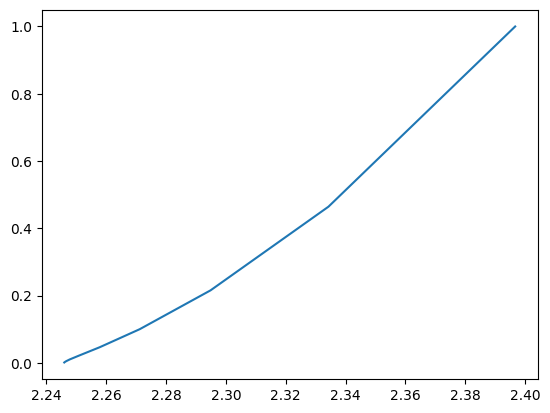

In [25]:
plt.plot(losses, lambdas)

### E04:
we saw that our 1-hot vectors merely select a row of W, so producing these vectors explicitly feels wasteful. Can you delete our use of F.one_hot in favor of simply indexing into rows of W?

In [57]:
def trigram_train(words, iterations=1000, lam=0.01, rand_seed=2147483647):
    # create the dataset
    xs, ys = [], []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
            ix1, ix2, ix3 = stoi[ch1], stoi[ch2], stoi[ch3]
            xs.append((ix1, ix2))
            ys.append(ix3)

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    num = ys.nelement()

    # randomly initialize 27 neurons' weights. each neuron receives 27 * 2 inputs
    g = torch.Generator().manual_seed(rand_seed)
    W = torch.randn((27 * 2, 27), generator=g, requires_grad=True)

    # gradient descent
    for k in range(iterations):
        # forward pass
        logits = W[xs[:, 0]] + W[xs[:, 1] + 27]  # <- merely select a row of W
        counts = logits.exp()  # counts, equivalent to N
        probs = counts / counts.sum(1, keepdims=True)  # probabilities for next character

        # with regularization
        loss = -probs[torch.arange(num), ys].log().mean() + lam * (W**2).mean()

        if k % 100 == 0:
            print(f"{loss.item()=}")

        # backward pass
        W.grad = None  # set to zero the gradient
        loss.backward()

        # update
        W.data += -50 * W.grad

    return W

In [58]:
trigram_weights = trigram_train(train_words)

loss.item()=4.196630477905273
loss.item()=2.2726023197174072
loss.item()=2.2594659328460693
loss.item()=2.2558205127716064
loss.item()=2.2543532848358154
loss.item()=2.2536427974700928
loss.item()=2.253248691558838
loss.item()=2.253006935119629
loss.item()=2.2528467178344727
loss.item()=2.252734899520874


### E05:
look up and use F.cross_entropy instead. You should achieve the same result. Can you think of why we'd prefer to use F.cross_entropy instead?

In [ ]:
def trigram_train(words, iterations=1000, lam=0.01, rand_seed=2147483647):
    # create the dataset
    xs, ys = [], []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
            ix1, ix2, ix3 = stoi[ch1], stoi[ch2], stoi[ch3]
            xs.append((ix1, ix2))
            ys.append(ix3)

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)

    # randomly initialize 27 neurons' weights. each neuron receives 27 * 2 inputs
    g = torch.Generator().manual_seed(rand_seed)
    W = torch.randn((27 * 2, 27), generator=g, requires_grad=True)

    xenc = F.one_hot(xs, num_classes=27).float().view(-1, 54)

    # gradient descent
    for k in range(iterations):
        # forward pass
        logits = xenc @ W  # predict log-counts
        loss = F.cross_entropy(logits, ys) + lam * (W**2).mean()

        if k % 100 == 0:
            print(f"{loss.item()=}")

        # backward pass
        W.grad = None  # set to zero the gradient
        loss.backward()

        # update
        W.data += -50 * W.grad

    return W

In [60]:
def trigram_eval(W, words):
    xs, ys = [], []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
            xs.append((stoi[ch1], stoi[ch2]))
            ys.append(stoi[ch3])
    xs = torch.tensor(xs)
    ys = torch.tensor(ys)

    with torch.no_grad():
        xenc = F.one_hot(xs, num_classes=27).float().view(-1, 54)
        logits = xenc @ W
        loss = F.cross_entropy(logits, ys)

    return loss.item()

In [54]:
trigram_weights = trigram_train(train_words)

loss.item()=4.196630477905273
loss.item()=2.2726027965545654
loss.item()=2.2594659328460693
loss.item()=2.2558205127716064
loss.item()=2.2543535232543945
loss.item()=2.2536427974700928
loss.item()=2.253248453140259
loss.item()=2.253006935119629
loss.item()=2.2528467178344727
loss.item()=2.252734899520874


In [55]:
print("trigram NN train:", trigram_eval(trigram_weights, train_words))
print("trigram NN dev:  ", trigram_eval(trigram_weights, dev_words))
print("trigram NN test: ", trigram_eval(trigram_weights, test_words))

trigram NN train: 2.4828410148620605
trigram NN dev:   2.4900927543640137
trigram NN test:  2.4805586338043213
